<div style='font-size: 30px; color: #000000;background-color: #9BEBA5;border: 3px solid black;text-align: center;'>
<div><b>Inductive learning <br> for indoor positioning systems </b></div>
</div>

### Table of contents
0. [Environment setup](#environment-setup)
1. [Graph construction](#graph-construction)
2. [Optimization](#optimization)
3. [Training](#training)
4. [Results](#results)

___

# 0. Environment setup

## Module loading

In [3]:
import os
import sys
import time
import glob
import json
import ast
import re
import importlib
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import itertools 
from itertools import product
import optuna

sys.path.append(os.path.abspath('../src'))

# Custom libraries
import indoorloc_enums
indoorloc_enums = importlib.reload(indoorloc_enums)
import indoorloc_data
indoorloc_data = importlib.reload(indoorloc_data)
import indoorloc_models
indoorloc_models = importlib.reload(indoorloc_models)
import indoorloc_vizs
indoorloc_vizs = importlib.reload(indoorloc_vizs)

import indoorloc_data as ildata
from indoorloc_data import (
    IndoorLocDataset, 
    IndoorLocResults, 
    IndoorLocGraphDataLoader, 
    IndoorLocPreprocessor, 
    IndoorLocGraphData
)
import indoorloc_vizs as ilvizs
import indoorloc_models as ilmodels
from indoorloc_models import (
    SAGERegressor,
    GNNRegressionTrainer
)

## Environment information

System characteristics and CUDA availability check.

In [2]:
ilvizs.EnvironmentInfo().show()


##################################################
	ENVIRONMENT INFORMATION
##################################################

Operating System: Linux
CPU: AMD Ryzen 5 2600 Six-Core Processor
RAM: 15.56 GB
--------------------------------------------------
Selected device cuda
CUDA version: 12.6
Number of available GPUs: 1
GPU 0: NVIDIA GeForce RTX 2060
--------------------------------------------------


----

# 1. Data preprocessing and graph construction

Data preprocessing and graph construction for each dataset from the grid’s parameter combinations.

Available datasets:
* **UJIIndoorLoc**: 'UJI1',
* **UTSIndoorLoc**: 'UTS1',
* **SODIndoorLoc**: 'SOD01', 'SOD02', 'SOD06',
* **TUTDatasets**: 'SAH1', 'TIE1', 'TUT1', 'TUT2', 'TUT3', 'TUT4', 'TUT5'

Available parameters:
* `normalization`: 'lineal', 'powed'
* `pca_components`: Between 0.0 and 1.0
* `distance_metric`: 'manhattan', 'cosine'
* `n_neighbors`: At least 1
* `graph_scheme`: 'transductive', 'inductive'

In [15]:
# Select datasets
dataset_selection = ['SOD01']
datasets = {name: name for name in dataset_selection}

# Generate parameter combinations
parameter_grid = {
    'normalization': ['powed'],
    'pca_components': [0.95],
    'distance_metric': ['cosine'],
    'n_neighbors': [1, 3, 5, 7, 9]
}

parameter_combinations = list(product(
    *parameter_grid.values()
))

# For each dataset and parameter combination, generate graph data
graph_data = {}
for dataset in tqdm(datasets, desc="Datasets"):
    graphdatas[dataset] = []
    dataset_structure = 'sodindoorloc' if dataset.startswith('SOD') else 'ujiindoorloc'

    for pca_components, norm, metric, n_neighbors in tqdm(
        parameter_combinations, 
        desc=f"Creating Graph Datas"
    ):
        # Load dataset
        df_original = IndoorLocDataset(
            dataset_structure=dataset_structure,
            path=f'../data/{dataset}/{dataset}', 
            header=None
        )

        # Preprocess dataset
        df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
            data=df_original, 
            normalization=norm,
            pca_components=pca_components
        )

        # Construct graph
        graphdata = IndoorLocGraphData().create_dataloader(
            dataset=df_preprocessed, 
            val_size=0.2,
            graph_params={
                'metric': metric, 
                'k': n_neighbors
            }
        )

        # Append graph data
        graph_data[dataset].append({
            'parameters':{
                'pca_components': pca_components,
                'normalization': norm,
                'metric': metric,
                'n_neighbors': n_neighbors,
            },
            'graphdata': graphdata}
        )


Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Creating Graph Datas:   0%|          | 0/5 [00:00<?, ?it/s]

Graph data encapsulated in the `PyTorch Geometric Data` object for the regression task.

In [13]:
graphdatas['SOD01'][0]['graphdata'].reg

Data(num_nodes=1795, val_mask=[1795], train_mask=[1795], test_mask=[1795], val_size=0.2, x=[1795, 12], num_features=12, edge_index=[2, 2730], k=1, y=[1795, 2], y_scaler=MinMaxScaler(), num_classes=0)

Creem un projecte amb Optuna per a cada conjunt de dades.  
En cada projecte o base de dades hi hauran tres estudis, un per a cada arquitectura GNN.  
En cada estudi s'entrenaran diverses combinacions paramètriques i es seleccionarà el model amb millor pèrdua de validació.

## Regressió

Carreguem les configuracions paramètriques dels grafs obtingudes anteriorment.

In [11]:
with open('graph_params_reg.json', 'r', encoding='utf-8') as f:
    graph_params_reg = json.load(f)

Executem Optuna per la tasca de regressió.

In [ ]:
dataset_names = ['UJI1', 'UTS1', 'SOD01','SOD02','SOD06',
                 'SAH1','TIE1','TUT1','TUT2','TUT3','TUT4','TUT5']
datasets = {name: name for name in dataset_names}
models = [GCNRegressor, GATRegressor, SAGERegressor]
n_trials = 100

for dataset in tqdm(datasets, desc="Datasets"):
    for model in tqdm(models, desc="Models"):
        df_original = IndoorLocDataset(
                                dataset_structure=dataset_structure,
                                path=f'../data/{dataset}/{dataset}', 
                                header=None 
                )
                
        df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
            data=df_original, 
            normalization=graph_params_reg[dataset]['normalization'],
            pca_components=graph_params_reg[dataset]['pca_components']
        )
        
        gdata = IndoorLocGraphData().create_dataloader(
                        dataset=df_preprocessed, 
                        val_size=0.2,
                        graph_params={
                            'k': graph_params_reg[dataset]['n_neighbors'],
                            'metric': graph_params_reg[dataset]['distance_metric']
                        },
                    )
        
        
        pbar = tqdm(total=n_trials, desc=f"{model.__name__}_{dataset}")
        def callback(study, trial):
            pbar.update(1)
            pbar.set_postfix({'Best MAE': study.best_value})
        
        GNNRegressionTrainer(dataset=dataset, max_epochs=800, patience=200).run_optuna_study(
            data=gdata.reg,
            model_class=model,
            study_name=f"{dataset}_{model.__name__}",
            direction="minimize",
            storage=f"sqlite:///optuna_transductive_reg_{dataset}_study.db",
            load_if_exists=True,
            n_trials=n_trials,
            callbacks=[callback]  
        )
        
        pbar.close()

## Classificació

Carreguem les configuracions paramètriques dels grafs obtingudes anteriorment.

In [ ]:
with open('graph_params_cls.json', 'r', encoding='utf-8') as f:
    graph_params_cls = json.load(f)

Executem Optuna per tasca de classificació.

In [ ]:
dataset_names = ['UJI1', 'UTS1', 'SOD01','SOD02','SOD06',
                 'SAH1','TIE1','TUT1','TUT2','TUT3','TUT4','TUT5']
datasets = {name: name for name in dataset_names}
models = [GCNClassifier, GATClassifier, SAGEClassifier]
n_trials = 100

for dataset in tqdm(datasets, desc="Datasets"):
    for model in tqdm(models, desc="Models"):
        df_original = IndoorLocDataset(
                                dataset_structure=dataset_structure,
                                path=f'../data/{dataset}/{dataset}', 
                                header=None 
                )
                
        df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
            data=df_original, 
            normalization=graph_params_cls[dataset]['normalization'],
            pca_components=graph_params_cls[dataset]['pca_components']
        )
        
        gdata = IndoorLocGraphData().create_dataloader(
                        dataset=df_preprocessed, 
                        val_size=0.2,
                        graph_params={
                            'k': graph_params_cls[dataset]['n_neighbors'],
                            'metric': graph_params_cls[dataset]['distance_metric']
                        },
                    )
        
        pbar = tqdm(total=n_trials, desc=f"{model.__name__}_{dataset}")
        def callback(study, trial):
            pbar.update(1)
            pbar.set_postfix({'Best MAE': study.best_value})
        
        GNNClassificationTrainer(dataset=dataset, max_epochs=500, patience=100).run_optuna_study(
            data=gdata.cls,
            model_class=model,
            study_name=f"{dataset}_{model.__name__}",
            direction="minimize",
            storage=f"sqlite:///optuna_transductive_cls_{dataset}_study.db",
            load_if_exists=True,
            n_trials=n_trials,
            callbacks=[callback]  
        )
        
        pbar.close()

## Selecció de la millora combinació

Desde la base de dades del projecte d'Optuna podem recuperar la millor combinació paramètrica.

In [ ]:
dataset = 'UJI1'
model = GATRegressor

storage = f"sqlite:///optuna_transductive_reg_{dataset}_study.db"
study_name = f"{dataset}_{model.__name__}"
study = optuna.load_study(
    study_name=study_name,
    storage=storage
)

best_params = study.best_params

## Carrega de paràmetres optimitzats

Carreguem els fitxers JSON amb les configuracions paramètriques òptimes de regressió i classificació.

In [17]:
with open('params_reg.json', 'r') as f:
    params_reg = json.load(f)

with open('params_cls.json', 'r') as f:
    params_cls = json.load(f)

## Regressió: Models Base

Per a cadascun dels conjunts de dades i arquitectures:
1. Carrega dels conjunts de dades
2. Preprocessament i construcció dels grafs òptims. 
3. Entrenament i validació dels models òptims.
4. Inferència sobre el subconjunt de test.

In [ ]:
models = [GCNRegressor, GATRegressor, SAGERegressor]
dataset_names = ['UJI1', 'UTS1', 'SOD01','SOD02','SOD06',
                 'SAH1','TIE1','TUT1','TUT2','TUT3','TUT4','TUT5']
datasets = {name: name for name in dataset_names}
learning_mode = "transductive"
task = "regression"

splits = 10

for dataset in tqdm(datasets, desc="Datasets"):
    print(dataset + " " + 75*"=")
    dataset_structure = 'sodindoorloc' if dataset.startswith('SOD') else 'ujiindoorloc'

    df_original = IndoorLocDataset(
                    dataset_structure=dataset_structure,
                    path=f'../data/{dataset}/{dataset}', 
                    header=None 
    )
    
    df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
        data=df_original, 
        normalization=params_reg[dataset]['graph_params']['normalization'],
        pca_components=params_reg[dataset]['graph_params']['pca_components']
    )
    
    gdata_splits = []
    for i in tqdm(range(splits), desc="Splitting dataset"):
        gdata = IndoorLocGraphData().create_dataloader(
            dataset=df_preprocessed, 
            val_size=0.2,
            graph_params={
                'k': params_reg[dataset]['graph_params']['n_neighbors'],
                'metric': params_reg[dataset]['graph_params']['distance_metric'], 
            },
            n_split=i,
        )
        gdata_splits.append(gdata)

    gdata = gdata_splits[0].reg
        
    for model in models:
        dataset_model_params = params_reg[dataset]['models'][model.__name__]
        
        print(f"{model.__name__}" + " " + 75*"*" )
        print(
            f"n_layers={2}, "
            f"hidden_dim_layer_0={dataset_model_params['hidden_dim_layer_0']}, "
            f"hidden_dim_layer_1={dataset_model_params['hidden_dim_layer_1']}, "
            f"dropout_layer_0={dataset_model_params['dropout_layer_0']}, "
            f"learning_rate={dataset_model_params['learning_rate']}, "
            f"optim_factor={0.9}, "
            f"weight_decay={dataset_model_params['weight_decay']}, "
            f"mlp_layers={dataset_model_params['mlp_layers']}"
        )

        model_params = {
            'input_dim': gdata.num_features,
            'hidden_dim': [dataset_model_params['hidden_dim_layer_0'], 
                           dataset_model_params['hidden_dim_layer_1']],
            'output_dim': 2, 
            'n_layers': 2,
            'dropout': dataset_model_params['dropout_layer_0'],
            'learning_rate': dataset_model_params['learning_rate'],
            'optim_factor': 0.9,
            'weight_decay': dataset_model_params['weight_decay'],
            'mlp_layers': dataset_model_params['mlp_layers']
        }
        if model.__name__ == 'GATRegressor':
            model_params['heads'] = [1, 1]

        trainer = GNNRegressionTrainer(dataset=dataset, max_epochs=800, patience=200).run_tests(
            data=gdata_splits, 
            model_class=model,
            parameters=model_params,
            verbose=2,
            show_train_process=False,
            model_path=f"../models/{learning_mode}_{model.__name__}_{dataset}.pth",
            log_path=f"../models/{learning_mode}_{model.__name__}_{dataset}.csv"
        )

## Classificació: Models Base

Per a cadascun dels conjunts de dades i arquitectures:
1. Carrega dels conjunts de dades
2. Preprocessament i construcció dels grafs òptims. 
3. Entrenament i validació dels models òptims.
4. Inferència sobre el subconjunt de test.

In [ ]:
models = [GCNClassifier, GATClassifier, SAGEClassifier]
dataset_names = ['UJI1', 'UTS1', 'SOD01', 'SAH1','TIE1','TUT1','TUT2','TUT3','TUT4','TUT5']
datasets = {name: name for name in dataset_names}
learning_mode = "transductive"
task = "classification"

splits = 10

for dataset in tqdm(datasets, desc="Datasets"):
    print(dataset + " " + 75*"=")
    dataset_structure = 'sodindoorloc' if dataset.startswith('SOD') else 'ujiindoorloc'

    df_original = IndoorLocDataset(
                    dataset_structure=dataset_structure,
                    path=f'../data/{dataset}/{dataset}', 
                    header=None 
    )
    
    df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
        data=df_original, 
        normalization=params_cls[dataset]['graph_params']['normalization'],
        pca_components=params_cls[dataset]['graph_params']['pca_components']
    )
    
    gdata_splits = []
    for i in tqdm(range(splits), desc="Splitting dataset"):
        gdata = IndoorLocGraphData().create_dataloader(
            dataset=df_preprocessed, 
            val_size=0.2,
            graph_params={
                'k': params_cls[dataset]['graph_params']['n_neighbors'],
                'metric': params_cls[dataset]['graph_params']['distance_metric'], 
            },
            n_split=i,
        )
        gdata_splits.append(gdata)

    gdata = gdata_splits[0].cls
        
    for model in models:
        dataset_model_params = params_cls[dataset]['models'][model.__name__]
        
        print(f"{model.__name__}" + " " + 75*"*" )
        print(
            f"n_layers={2}, "
            f"hidden_dim_layer_0={dataset_model_params['hidden_dim_layer_0']}, "
            f"hidden_dim_layer_1={dataset_model_params['hidden_dim_layer_1']}, "
            f"dropout_layer_0={dataset_model_params['dropout_layer_0']}, "
            f"learning_rate={dataset_model_params['learning_rate']}, "
            f"optim_factor={0.9}, "
            f"weight_decay={dataset_model_params['weight_decay']}, "
            f"mlp_layers={dataset_model_params['mlp_layers']}"
            f"edges={gdata.num_edges}"

        )

        model_params = {
            'input_dim': gdata.num_features,
            'hidden_dim': [dataset_model_params['hidden_dim_layer_0'], 
                           dataset_model_params['hidden_dim_layer_1']],
            'output_dim': gdata.num_classes, 
            'n_layers': 2,
            'dropout': [dataset_model_params['dropout_layer_0']],
            'learning_rate': dataset_model_params['learning_rate'],
            'optim_factor': 0.9,
            'weight_decay': dataset_model_params['weight_decay'],
            'mlp_layers': dataset_model_params['mlp_layers']
        }
        if model.__name__ == 'GATClassifier':
            model_params['heads'] = [1, 1]

        trainer = GNNClassificationTrainer(dataset=dataset, max_epochs=500, patience=100).run_tests(
            data=gdata_splits, 
            model_class=model,
            parameters=model_params,
            verbose=2,
            show_train_process=False,
            model_path=f"../models/{learning_mode}_{model.__name__}_{dataset}.pth",
            log_path=f"../models/{learning_mode}_{model.__name__}_{dataset}.csv"
        )

## Regressió: Meta-models

Per a cadascun dels conjunts de dades:
1. Càrrega dels conjunts de dades
2. Preprocessament i construcció dels grafs òptims.
3. Càrrega de models base pre-entrenats en la tasca de regressió.
4. Entrenament i validació dels meta-models.
5. Inferència sobre el subconjunt de test.

In [ ]:
datasets = ['SAH1','TIE1','TUT1','TUT2','TUT3','TUT4','TUT5',
            'SOD01', 'SOD02','SOD06', 'UJI1', 'UTS1']

model = EnsembleStackingRegressor.__name__
splits = 10

for dataset in tqdm(datasets, desc="Datasets"):
    dataset_structure = 'sodindoorloc' if dataset.startswith('SOD') else 'ujiindoorloc'

    df_original = IndoorLocDataset(
                    dataset_structure=dataset_structure,
                    path=f'../data/{dataset}/{dataset}', 
                    header=None 
    )
    
    df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
        data=df_original, 
        normalization=params_reg[dataset]['graph_params']['normalization'],
        pca_components=params_reg[dataset]['graph_params']['pca_components']
    )
    
    gdata_splits = []
    for i in tqdm(range(splits), desc="Splitting dataset"):
        gdata = IndoorLocGraphData().create_dataloader(
            dataset=df_preprocessed, 
            val_size=0.2,
            graph_params={
                'k': params_reg[dataset]['graph_params']['n_neighbors'],
                'metric': params_reg[dataset]['graph_params']['distance_metric'], 
            },
            n_split=i,
        )
        gdata_splits.append(gdata)

    gdata = gdata_splits[0].reg
    
    gcn_params = params_reg[dataset]['models']['GCNRegressor']
    gcn_params = {
        'input_dim': gdata.num_features,
        'hidden_dim': [gcn_params['hidden_dim_layer_0'], 
                       gcn_params['hidden_dim_layer_1']],
        'output_dim': 2, 
        'n_layers': 2,
        'dropout': gcn_params['dropout_layer_0'],
        'learning_rate': gcn_params['learning_rate'],
        'optim_factor': 0.9,
        'weight_decay': gcn_params['weight_decay'],
        'mlp_layers': gcn_params['mlp_layers']
    }

    gat_params = params_reg[dataset]['models']['GATRegressor']
    gat_params = {
        'input_dim': gdata.num_features,
        'hidden_dim': [gat_params['hidden_dim_layer_0'], 
                       gat_params['hidden_dim_layer_1']],
        'output_dim': 2, 
        'n_layers': 2,
        'heads': [1, 1],
        'dropout': gat_params['dropout_layer_0'],
        'learning_rate': gat_params['learning_rate'],
        'optim_factor': 0.9,
        'weight_decay': gat_params['weight_decay'],
        'mlp_layers': gat_params['mlp_layers']
    }
    
    sage_params = params_reg[dataset]['models']['SAGERegressor']
    sage_params = {
        'input_dim': gdata.num_features,
        'hidden_dim': [sage_params['hidden_dim_layer_0'], 
                       sage_params['hidden_dim_layer_1']],
        'output_dim': 2, 
        'n_layers': 2,
        'dropout': sage_params['dropout_layer_0'],
        'learning_rate': sage_params['learning_rate'],
        'optim_factor': 0.9,
        'weight_decay': sage_params['weight_decay'],
        'mlp_layers': sage_params['mlp_layers']
    }

    models = {
       'gcn':{
            'path':f"../models/transductive_regression/transductive_GCNRegressor_{dataset}.pth",
            'model_class':GCNRegressor,
            'params':gcn_params
        },
        'gat':{
            'path':f"../models/transductive_regression/transductive_GATRegressor_{dataset}.pth",
            'model_class':GATRegressor,
           'params':gat_params        
        },
        'sage':{
            'path':f"../models/transductive_regression/transductive_SAGERegressor_{dataset}.pth",
            'model_class':SAGERegressor,
            'params':sage_params        
        }
    }

    for r in [2, 3]:
        for combo in itertools.combinations(list(models.keys()), r):
            print(f"Combinació: {combo}")
    
            combo_models = {k: models[k] for k in combo}
            if len(combo) == 2:
                combo_name = f"{combo[0]}_{combo[1]}"
            if len(combo) == 3:
                combo_name = f"{combo[0]}_{combo[1]}_{combo[2]}"
                
            ensemble_params = {
                'models': combo_models,
                'n_layers': 4,
                'hidden_dim':[128, 64, 32, 16],
                'output_dim':2,
                'learning_rate':0.01,
                'weight_decay':0.0001,
                'optim_factor':0.9,
                'dropout':0
            }
        
            trainer = GNNRegressionTrainer(dataset=dataset, max_epochs=800, patience=200).run_tests(
                data=gdata_splits, 
                model_class=EnsembleStackingRegressor,
                parameters=ensemble_params,
                verbose=2,
                show_train_process=False,
                model_path=f"../models/transductive_EnsembleStackingRegressor_{dataset}_{combo_name}.pth",
                log_path=f"../models/transductive_EnsembleStackingRegressor_{dataset}_{combo_name}.csv")
    

## Classificació: Meta-models

Per a cadascun dels conjunts de dades:
1. Càrrega dels conjunts de dades
2. Preprocessament i construcció dels grafs òptims.
3. Càrrega de models base pre-entrenats en la tasca de classificació.
4. Entrenament i validació dels meta-models.
5. Inferència sobre el subconjunt de test.

In [ ]:
datasets = ['SAH1','TUT1','TUT2','TUT3','TUT4','TUT5',
            'UJI1','UTS1','SOD01']
learning_mode = "transductive"
task = "classification"

model = EnsembleStackingClassifier.__name__
splits = 10

for dataset in tqdm(datasets, desc="Datasets"):
    dataset_structure = 'sodindoorloc' if dataset.startswith('SOD') else 'ujiindoorloc'

    df_original = IndoorLocDataset(
                    dataset_structure=dataset_structure,
                    path=f'../data/{dataset}/{dataset}', 
                    header=None 
    )
    
    df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
        data=df_original, 
        normalization=params_cls[dataset]['graph_params']['normalization'],
        pca_components=params_cls[dataset]['graph_params']['pca_components']
    )
    
    gdata_splits = []
    for i in tqdm(range(splits), desc="Splitting dataset"):
        gdata = IndoorLocGraphData().create_dataloader(
            dataset=df_preprocessed, 
            val_size=0.2,
            graph_params={
                'k': params_cls[dataset]['graph_params']['n_neighbors'],
                'metric': params_cls[dataset]['graph_params']['distance_metric'], 
            },
            n_split=i,
        )
        gdata_splits.append(gdata)

    gdata = gdata_splits[0].cls
    
    gcn_params = params_cls[dataset]['models']['GCNClassifier']
    gcn_params = {
        'input_dim': gdata.num_features,
        'hidden_dim': [gcn_params['hidden_dim_layer_0'], 
                       gcn_params['hidden_dim_layer_1']],
        'output_dim': gdata.num_classes, 
        'n_layers': 2,
        'dropout': [gcn_params['dropout_layer_0']],
        'learning_rate': gcn_params['learning_rate'],
        'optim_factor': 0.9,
        'weight_decay': gcn_params['weight_decay'],
        'mlp_layers': gcn_params['mlp_layers']
    }

    gat_params = params_cls[dataset]['models']['GATClassifier']
    gat_params = {
        'input_dim': gdata.num_features,
        'hidden_dim': [gat_params['hidden_dim_layer_0'], 
                       gat_params['hidden_dim_layer_1']],
        'output_dim': gdata.num_classes, 
        'n_layers': 2,
        'heads': [1, 1],
        'dropout': [gat_params['dropout_layer_0']],
        'learning_rate': gat_params['learning_rate'],
        'optim_factor': 0.9,
        'weight_decay': gat_params['weight_decay'],
        'mlp_layers': gat_params['mlp_layers']
    }
    
    sage_params = params_cls[dataset]['models']['SAGEClassifier']
    sage_params = {
        'input_dim': gdata.num_features,
        'hidden_dim': [sage_params['hidden_dim_layer_0'], 
                       sage_params['hidden_dim_layer_1']],
        'output_dim': gdata.num_classes, 
        'n_layers': 2,
        'dropout': [sage_params['dropout_layer_0']],
        'learning_rate': sage_params['learning_rate'],
        'optim_factor': 0.9,
        'weight_decay': sage_params['weight_decay'],
        'mlp_layers': sage_params['mlp_layers']
    }

    models = {
        'gcn':{
            'path':f"../models/transductive_classification/transductive_GCNClassifier_{dataset}.pth",
            'model_class':GCNClassifier,
            'params':gcn_params
        },
        'gat':{
            'path':f"../models/transductive_classification/transductive_GATClassifier_{dataset}.pth",
            'model_class':GATClassifier,
            'params':gat_params        
        },
        'sage':{
            'path':f"../models/transductive_classification/transductive_SAGEClassifier_{dataset}.pth",
            'model_class':SAGEClassifier,
            'params':sage_params        
        }
    }

    model_keys = list(models.keys())

    for r in [2,3]:
        for combo in itertools.combinations(model_keys, r):
            print(f"Combinació: {combo}")
    
            combo_models = {k: models[k] for k in combo}
            
            if len(combo) == 2:
                combo_name = f"{combo[0]}_{combo[1]}"
            if len(combo) == 3:
                combo_name = f"{combo[0]}_{combo[1]}_{combo[2]}"
                
            ensemble_params = {
                'models': combo_models,
                'n_layers': 4,
                'hidden_dim':[128, 64, 32, 16],
                'output_dim':gdata.num_classes,
                'learning_rate':0.01,
                'weight_decay':0.0001,
                'optim_factor':0.9,
                'dropout':0.2
            }
        
            trainer = GNNClassificationTrainer(dataset=dataset, max_epochs=800, patience=200).run_tests(
                data=gdata_splits, 
                model_class=EnsembleStackingClassifier,
                parameters=ensemble_params,
                verbose=2,
                show_train_process=False,
                model_path=f"../models/transductive_EnsembleStackingClassifier_{dataset}_{combo_name}.pth",
                log_path=f"../models/transductive_EnsembleStackingClassifier_{dataset}_{combo_name}.csv")
    

## Classificació: Models Base

Carreguem els resultats obtinguts dels models base per a la tasca de classificació.

In [28]:
path = "../models/transductive_classification/*.csv"

csv_files = glob.glob(path)
cols = ['mean_accuracy','accuracy_std', 'max_accuracy', 'precision_macro', 'confusion_matrix',
        'mean_train_time','mean_train_time_std', 'mean_test_time', 'mean_test_time_std' , 'n_parameters']

dfs = []
for f in csv_files:
    fname = os.path.splitext(os.path.basename(f))[0] 
    
    parts = fname.split('_')
    if len(parts) >= 3:
        model_name = parts[1]        
        tie_name = parts[2]         
    else:
        data_split = model_name = tie_name = 'unknown'

    df_temp = pd.read_csv(f, usecols=cols)
    df_temp['Model'] = model_name
    df_temp['Conjunt'] = tie_name
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
dataset_order = ['UJI1', 'UTS1', 'SOD01', 'SAH1', 'TIE1', 'TUT1', 'TUT2', 'TUT3', 'TUT4', 'TUT5']
model_order = ['GCNClassifier', 'GATClassifier', 'SAGEClassifier']

df['Conjunt'] = pd.Categorical(df['Conjunt'], categories=dataset_order, ordered=True)
df['Model'] = pd.Categorical(df['Model'], categories=model_order, ordered=True)
df['Model'] = df['Model'].str.replace('Classifier', '', regex=False)

df_sorted = df.sort_values(['Conjunt', 'Model']).reset_index(drop=True)
df_cls = df_sorted[['Conjunt', 'Model'] + [c for c in df_sorted.columns if c not in ['Conjunt', 'Model']]]

Carreguem les variables estructurals.

In [29]:
gdatas_cls = []
for dataset in dataset_order:
    dataset_structure = 'sodindoorloc' if dataset.startswith('SOD') else 'ujiindoorloc'
    df_original = IndoorLocDataset(
                    dataset_structure=dataset_structure,
                    path=f'../data/{dataset}/{dataset}', 
                    header=None 
    )
    
    df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
        data=df_original, 
        normalization=params_cls[dataset]['graph_params']['normalization'],
        pca_components=params_cls[dataset]['graph_params']['pca_components']
    )
    
    gdata_splits = []
    for i in range(1):
        gdata = IndoorLocGraphData().create_dataloader(
            dataset=df_preprocessed, 
            val_size=0.2,
            graph_params={
                'k': params_cls[dataset]['graph_params']['n_neighbors'],
                'metric': params_cls[dataset]['graph_params']['distance_metric'], 
            },
            n_split=i,
        )
    gdatas_cls.append(gdata)

Combinem els dataframes dels resultats amb les variables estrcturals per l'analisi d'eficiència computacional.

In [30]:
dataset_info = []
for i, conjunt in enumerate(dataset_order):
    dataset_info.append({
        'Conjunt': conjunt,
        'Característiques': gdatas_cls[i].cls.num_features,
        'Nodes': gdatas_cls[i].cls.num_nodes,
        'Enllaços': gdatas_cls[i].cls.num_edges
    })
    
df_datasets = pd.DataFrame(dataset_info)
df_performance_cls = df_cls.merge(
    df_datasets,
    on='Conjunt',
    how='left'
)

In [31]:
df_performance_cls.head(5)

,Conjunt,Model,mean_accuracy,accuracy_std,max_accuracy,precision_macro,confusion_matrix,mean_train_time,mean_train_time_std,mean_test_time,mean_test_time_std,n_parameters,Característiques,Nodes,Enllaços
0,UJI1,GAT,95.09,0.51,95.68,94.05,"[[738, 36, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [...",8.93,1.77,0.00855,0.00072,144397,520,20972,91674
1,UJI1,GCN,95.20,0.66,96.13,94.41,"[[733, 36, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], ...",8.28,2.28,0.01020,0.00056,143245,520,20972,91674
2,UJI1,SAGE,95.28,0.80,96.04,94.22,"[[739, 34, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [...",18.66,4.28,0.01685,0.00050,443821,520,20972,91674
3,UTS1,GAT,96.01,0.37,96.39,95.74,"[[90, 30, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.26,2.05,0.00446,0.00007,197296,589,9496,40198
4,UTS1,GCN,95.80,0.28,96.39,95.56,"[[90, 30, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",8.45,1.25,0.00524,0.00011,154208,589,9496,40198


### Problemàtica amb el conjunt de dades TIE1

Mostrem la distribució de mostres de les primeres dues plantes per evidenciar la problemàtica amb aquest conjunt de dades.

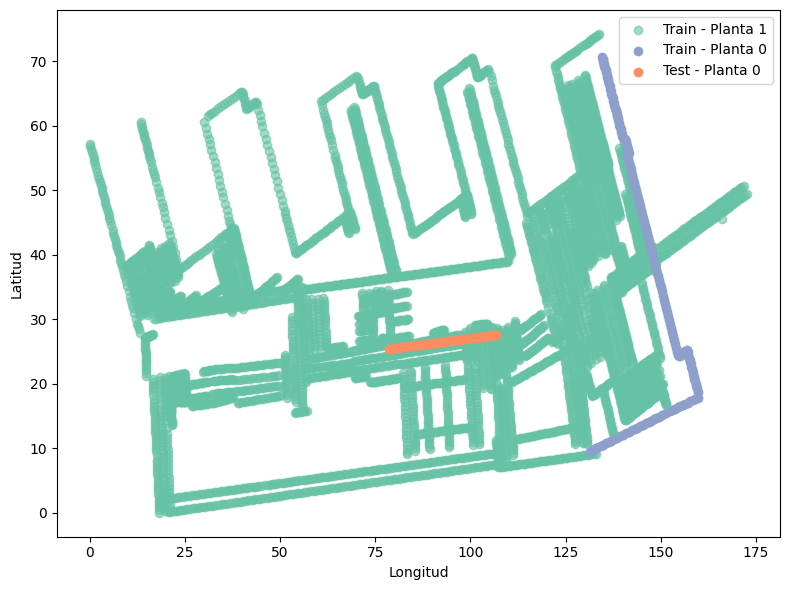

In [119]:
dataset = 'TIE1'
df_original = IndoorLocDataset(
    dataset_structure=dataset_structure,
    path=f'../data/{dataset}/{dataset}', 
    header=None 
)
df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
    data=df_original, 
    normalization=params_cls[dataset]['graph_params']['normalization'],
    pca_components=params_cls[dataset]['graph_params']['pca_components']
)

ilvizs.plot_building_floor_distribution(df_preprocessed)

### Matrius de confussió

In [33]:
def mean_distance_error(confusion_matrix):
    cm = np.asarray(confusion_matrix)
    n_classes = cm.shape[0]

    i = np.arange(n_classes).reshape(-1, 1)
    j = np.arange(n_classes).reshape(1, -1)
    distance_matrix = np.abs(i - j)

    total_samples = cm.sum()
    weighted_error = np.sum(cm * distance_matrix)

    return weighted_error / total_samples

Mostra la matriu de confussió per un conjunt de dades i model.

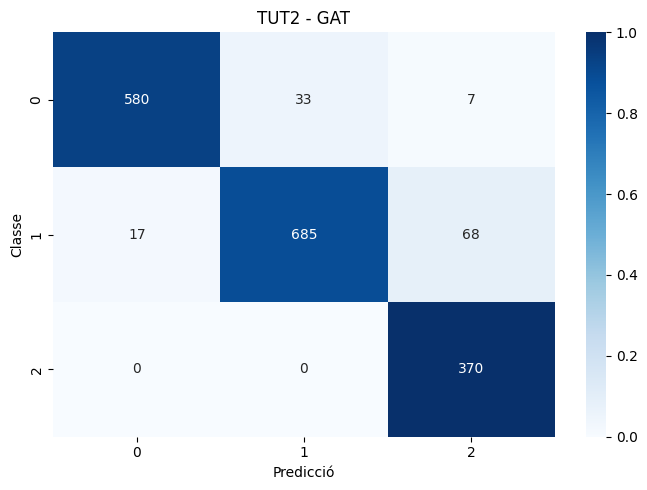

In [12]:
dataset = 'TUT2'
model = 'GAT'

df_cls = df_cls.copy() 
df_cls['confusion_matrix_parsed'] = df_cls['confusion_matrix'].apply(ast.literal_eval)
row = df_cls[(df_cls['Conjunt'] == dataset) & (df_cls['Model'] == model)].iloc[0]
cm = np.array(row['confusion_matrix_parsed'])

ilvizs.plot_confusion_matrix(cm, dataset, model)

## Classificació: Meta-models

Carreguem els resultats obtinguts dels meta-models per a la tasca de classificació.

In [36]:
path = "../models/transductive_classification/ensemble/transductive_EnsembleStackingClassifier_*.csv"
csv_files = glob.glob(path)
cols = ['mean_accuracy','accuracy_std', 'max_accuracy', 'mean_train_time', 'confusion_matrix',
        'mean_train_time_std', 'mean_test_time', 'mean_test_time_std' , 'n_parameters']

dfs = []

for f in csv_files:
    fname = os.path.splitext(os.path.basename(f))[0]  
    parts = fname.split('_')
    if len(parts) == 5:
        model_name = parts[3] + "_" + parts[4]        
        dataset_name = parts[2]          
    else:
        model_name = parts[3] + "_" + parts[4] + "_" + parts[5]      
        dataset_name = parts[2]          

    df_temp = pd.read_csv(f, usecols=cols)
    df_temp['Model'] = model_name
    df_temp['Conjunt'] = dataset_name
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

conjunt_order = ['UJI1', 'UTS1', 'SOD01', 'SAH1', 'TUT1', 'TUT2', 'TUT3', 'TUT4', 'TUT5']
model_order = ['gcn_gat', 'gcn_sage', 'gat_sage', 'gcn_gat_sage']

df['Conjunt'] = pd.Categorical(df['Conjunt'], categories=conjunt_order, ordered=True)
df['Model'] = pd.Categorical(df['Model'], categories=model_order, ordered=True)

df_sorted = df.sort_values(['Conjunt', 'Model']).reset_index(drop=True)
cols = ['Conjunt', 'Model'] + [c for c in df_sorted.columns if c not in ['Conjunt', 'Model']]
df_meta_cls = df_sorted[cols]
df_meta_cls['Model'] = df_meta_cls['Model'].astype(str).replace({
    'gcn_sage': 'GCN-SAGE',
    'gcn_gat': 'GCN-GAT',
    'gat_sage': 'GAT-SAGE',
    'gcn_gat_sage': 'GCN-GAT-SAGE'
})
df_meta_cls.head(5)

,Conjunt,Model,mean_accuracy,accuracy_std,max_accuracy,confusion_matrix,mean_train_time,mean_train_time_std,mean_test_time,mean_test_time_std,n_parameters
0,UJI1,GCN-GAT,95.04,0.07,95.14,"[[730, 50, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [...",19.24,7.70,0.01880,0.00070,14541
1,UJI1,GCN-SAGE,95.15,0.11,95.32,"[[748, 32, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [...",42.33,12.97,0.03119,0.00248,14541
2,UJI1,GAT-SAGE,95.46,0.26,95.77,"[[748, 32, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [...",31.41,12.98,0.02927,0.00254,14541
3,UJI1,GCN-GAT-SAGE,95.18,0.25,95.68,"[[742, 38, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [...",33.96,16.42,0.03624,0.00242,16205
4,UTS1,GCN-GAT,96.03,0.31,96.39,"[[90, 30, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",12.01,4.12,0.01046,0.00100,15360


### Matriu de confussió

Generem les matrius de confussió dels meta-models.

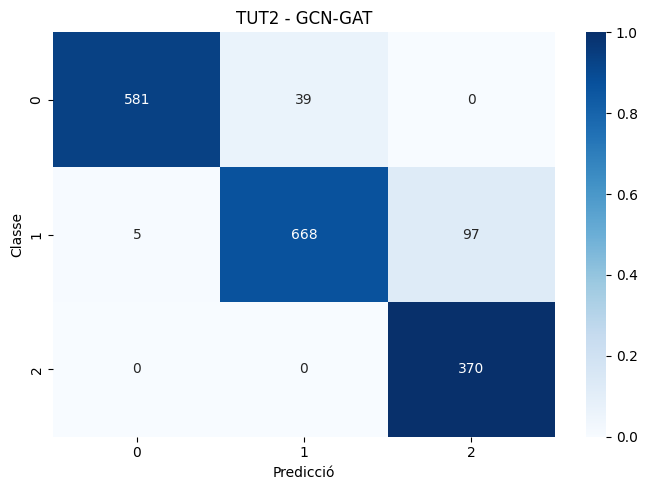

In [35]:
dataset = 'TUT2'
model = 'GCN-GAT'

df_meta_cls = df_meta_cls.copy() 
df_meta_cls['confusion_matrix_parsed'] = df_meta_cls['confusion_matrix'].apply(ast.literal_eval)
row = df_meta_cls[(df_meta_cls['Conjunt'] == dataset) & (df_meta_cls['Model'] == model)].iloc[0]
cm = np.array(row['confusion_matrix_parsed'])

ilvizs.plot_confusion_matrix(cm, dataset, model)

## Regressió: Models Base

Carreguem els resultats obtinguts dels models base per a la tasca de regressió.

In [69]:
path = "../models/transductive_regression/*.csv"

csv_files = glob.glob(path)
cols = ['mpe','mae', 'mae_x', 'mae_y',
        'mean_train_time','mean_train_time_std', 'mean_test_time', 'mean_test_time_std' , 'n_parameters']

dfs = []
for f in csv_files:
    fname = os.path.splitext(os.path.basename(f))[0] 
    
    parts = fname.split('_')
    if len(parts) >= 3:
        model_name = parts[1]        
        tie_name = parts[2]         
    else:
        data_split = model_name = tie_name = 'unknown'

    df_temp = pd.read_csv(f, usecols=cols)
    df_temp['Model'] = model_name
    df_temp['Conjunt'] = tie_name
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
dataset_order = ['UJI1', 'UTS1', 'SOD01', 'SOD02', 'SOD06', 
                 'SAH1', 'TIE1', 'TUT1', 'TUT2', 'TUT3', 'TUT4', 'TUT5']
model_order = ['GCNRegressor', 'GATRegressor', 'SAGERegressor']

df['Conjunt'] = pd.Categorical(df['Conjunt'], categories=dataset_order, ordered=True)
df['Model'] = pd.Categorical(df['Model'], categories=model_order, ordered=True)
df['Model'] = df['Model'].str.replace('Regressor', '', regex=False)

df_sorted = df.sort_values(['Conjunt', 'Model']).reset_index(drop=True)
df_reg = df_sorted[['Conjunt', 'Model'] + [c for c in df_sorted.columns if c not in ['Conjunt', 'Model']]]

Carreguem les variables estructurals.

In [ ]:
gdatas_reg = []
for dataset in dataset_order:
    dataset_structure = 'sodindoorloc' if dataset.startswith('SOD') else 'ujiindoorloc'
    df_original = IndoorLocDataset(
                    dataset_structure=dataset_structure,
                    path=f'../data/{dataset}/{dataset}', 
                    header=None 
    )
    
    df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
        data=df_original, 
        normalization=params_reg[dataset]['graph_params']['normalization'],
        pca_components=params_reg[dataset]['graph_params']['pca_components']
    )
    
    gdata_splits = []
    for i in range(1):
        gdata = IndoorLocGraphData().create_dataloader(
            dataset=df_preprocessed, 
            val_size=0.2,
            graph_params={
                'k': params_reg[dataset]['graph_params']['n_neighbors'],
                'metric': params_reg[dataset]['graph_params']['distance_metric'], 
            },
            n_split=i,
        )
    gdatas_reg.append(gdata)

Combinem els dataframes dels resultats amb les variables estrcturals per l'analisi d'eficiència computacional.

In [ ]:
dataset_info = []
for i, conjunt in enumerate(dataset_order):
    dataset_info.append({
        'Conjunt': conjunt,
        'Característiques': gdatas_reg[i].reg.num_features,
        'Nodes': gdatas_reg[i].reg.num_nodes,
        'Enllaços': gdatas_reg[i].reg.num_edges
    })

df_datasets = pd.DataFrame(dataset_info)
df_performance_reg = df_reg.merge(
    df_datasets,
    on='Conjunt',
    how='left'
)

### Funció de distribució acumulada (CDF)

#### Exemple

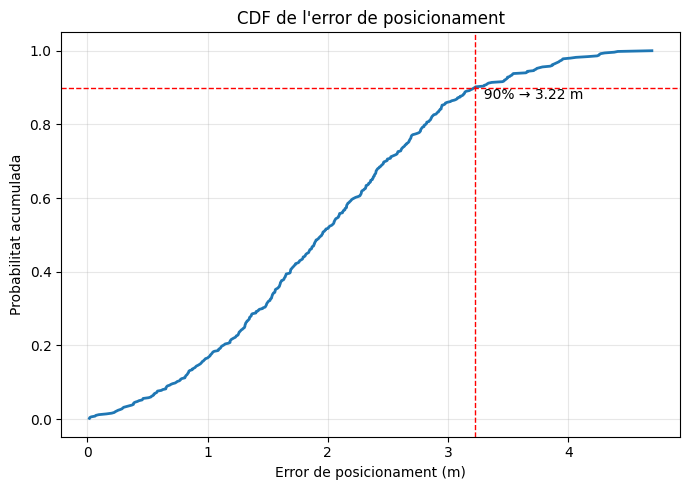

In [71]:
np.random.seed(0)
errors = np.abs(np.random.normal(loc=2, scale=1.0, size=500))
errors_sorted = np.sort(errors)
cdf = np.arange(1, len(errors_sorted) + 1) / len(errors_sorted)

p = 0.90
error_p90 = np.percentile(errors, p * 100)

plt.figure(figsize=(7, 5))
plt.plot(errors_sorted, cdf, label="CDF de l'error", linewidth=2)

plt.axhline(y=p, color='red', linestyle='--', linewidth=1)
plt.axvline(x=error_p90, color='red', linestyle='--', linewidth=1)

plt.text(
    error_p90, p,
    f"  {p*100:.0f}% → {error_p90:.2f} m",
    verticalalignment='top',
    color='black'
)

plt.xlabel("Error de posicionament (m)")
plt.ylabel("Probabilitat acumulada")
plt.title("CDF de l'error de posicionament")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### Per conjunt de dades i model

Carreguem els errors obtinguts en els experiments de regressió.

In [75]:
dataset= 'UJI1'
results_dict = {
    "GCN":{
        'label': 'GCN',
        'path': f'../models/cdf_regression/transductive_GCNRegressor_{dataset}_errors.npy'
    },
    "GAT":{
        'label': 'GAT',
        'path': f'../models/cdf_regression/transductive_GATRegressor_{dataset}_errors.npy'
    },
    "GraphSAGE":{
        'label': 'GraphSAGE',
        'path': f'../models/cdf_regression/transductive_SAGERegressor_{dataset}_errors.npy'
    },
    "Meta-model 2":{
    'label': 'Meta-model 2',
    'path': f'../models/cdf_regression/transductive_EnsembleStackingRegressor_{dataset}_2_errors.npy'
    },
    "Meta-model 3":{
    'label': 'Meta-model 3',
    'path': f'../models/cdf_regression/transductive_EnsembleStackingRegressor_{dataset}_3_errors.npy'
    }
}

Mostrem la funció de distribució acumulada

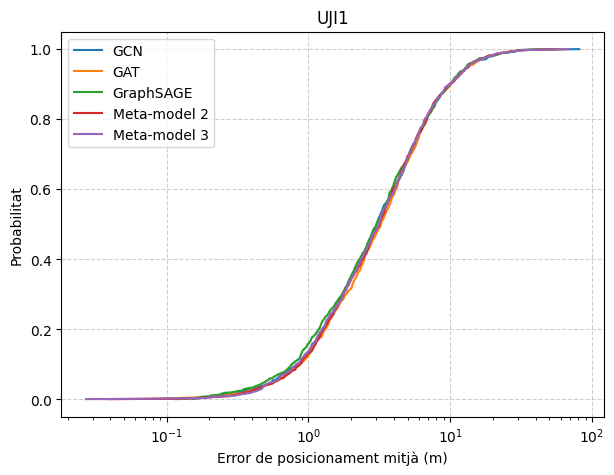

In [80]:
ilvizs.plot_cdf(results_dict, dataset)

## Regressió: Meta-models

Carreguem els resultats obtinguts dels meta-models per a la tasca de regressió.

In [ ]:
path = "../models/transductive_regression/ensemble/transductive_EnsembleStackingRegressor_*.csv"
csv_files = glob.glob(path)
cols = ['mpe','mae', 'mae_x', 'mae_y',
        'mean_train_time', 'mean_train_time_std', 'mean_test_time', 'mean_test_time_std' , 'n_parameters']

dfs = []

for f in csv_files:
    fname = os.path.splitext(os.path.basename(f))[0]  
    parts = fname.split('_')
    if len(parts) == 5:
        model_name = parts[3] + "_" + parts[4]        
        dataset_name = parts[2]          
    else:
        model_name = parts[3] + "_" + parts[4] + "_" + parts[5]      
        dataset_name = parts[2]          

    df_temp = pd.read_csv(f, usecols=cols)
    df_temp['Model'] = model_name
    df_temp['Conjunt'] = dataset_name
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

conjunt_order = ['UJI1', 'UTS1', 'SOD01', 'SOD02','SOD06', 'SAH1', 'TIE1', 'TUT1', 'TUT2', 'TUT3', 'TUT4', 'TUT5']
model_order = ['gcn_gat', 'gcn_sage', 'gat_sage', 'gcn_gat_sage']

df['Conjunt'] = pd.Categorical(df['Conjunt'], categories=conjunt_order, ordered=True)
df['Model'] = pd.Categorical(df['Model'], categories=model_order, ordered=True)

df_sorted = df.sort_values(['Conjunt', 'Model']).reset_index(drop=True)
cols = ['Conjunt', 'Model'] + [c for c in df_sorted.columns if c not in ['Conjunt', 'Model']]
df_meta_reg = df_sorted[cols]
df_meta_reg['Model'] = df_meta_reg['Model'].replace({
    'gcn_sage': 'GCN-SAGE',
    'gcn_gat': 'GCN-GAT',
    'gat_sage': 'GAT-SAGE',
    'gcn_gat_sage': 'GCN-GAT-SAGE'
})
df_meta_reg

## Eficiència computacional

Combinanem els resultats de tots els Models Base.

In [43]:
df_performance_total = pd.concat([df_performance_reg, df_performance_cls], ignore_index=True)
df_performance_total = df_performance_total.rename(columns={
    "n_parameters": "Paràmetres entrenables",
    "mean_train_time": "t (train)",
    "mean_test_time": "t (test)"
})

### Correlació temporal

Mostrem la correlació entre el temps d'entrenament i d'inferència.

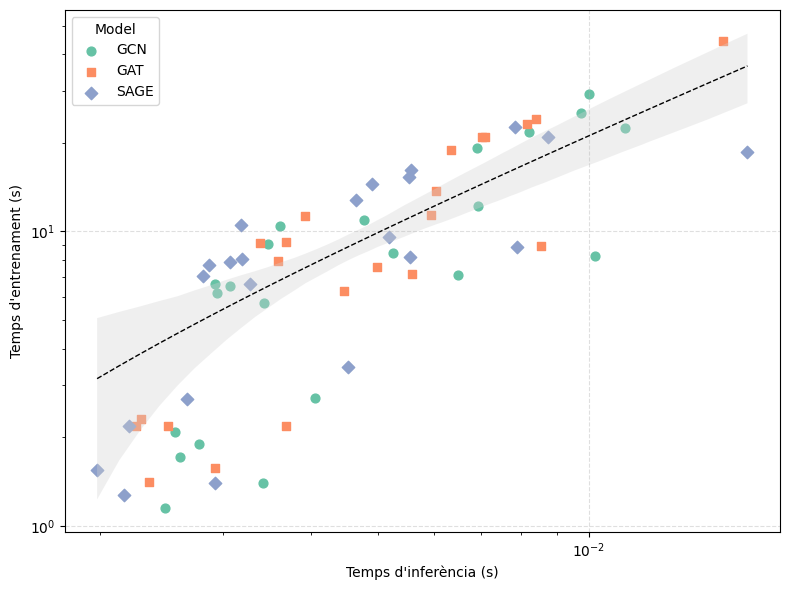

R² = 0.657


np.float64(0.6571811042391982)

In [44]:
ilvizs.plot_time_correlation(df_performance_total)

### Efectes parcials

Mostrem els efectes parcials de les variables que poden tenir una influència més gran en el temps d'inferència.

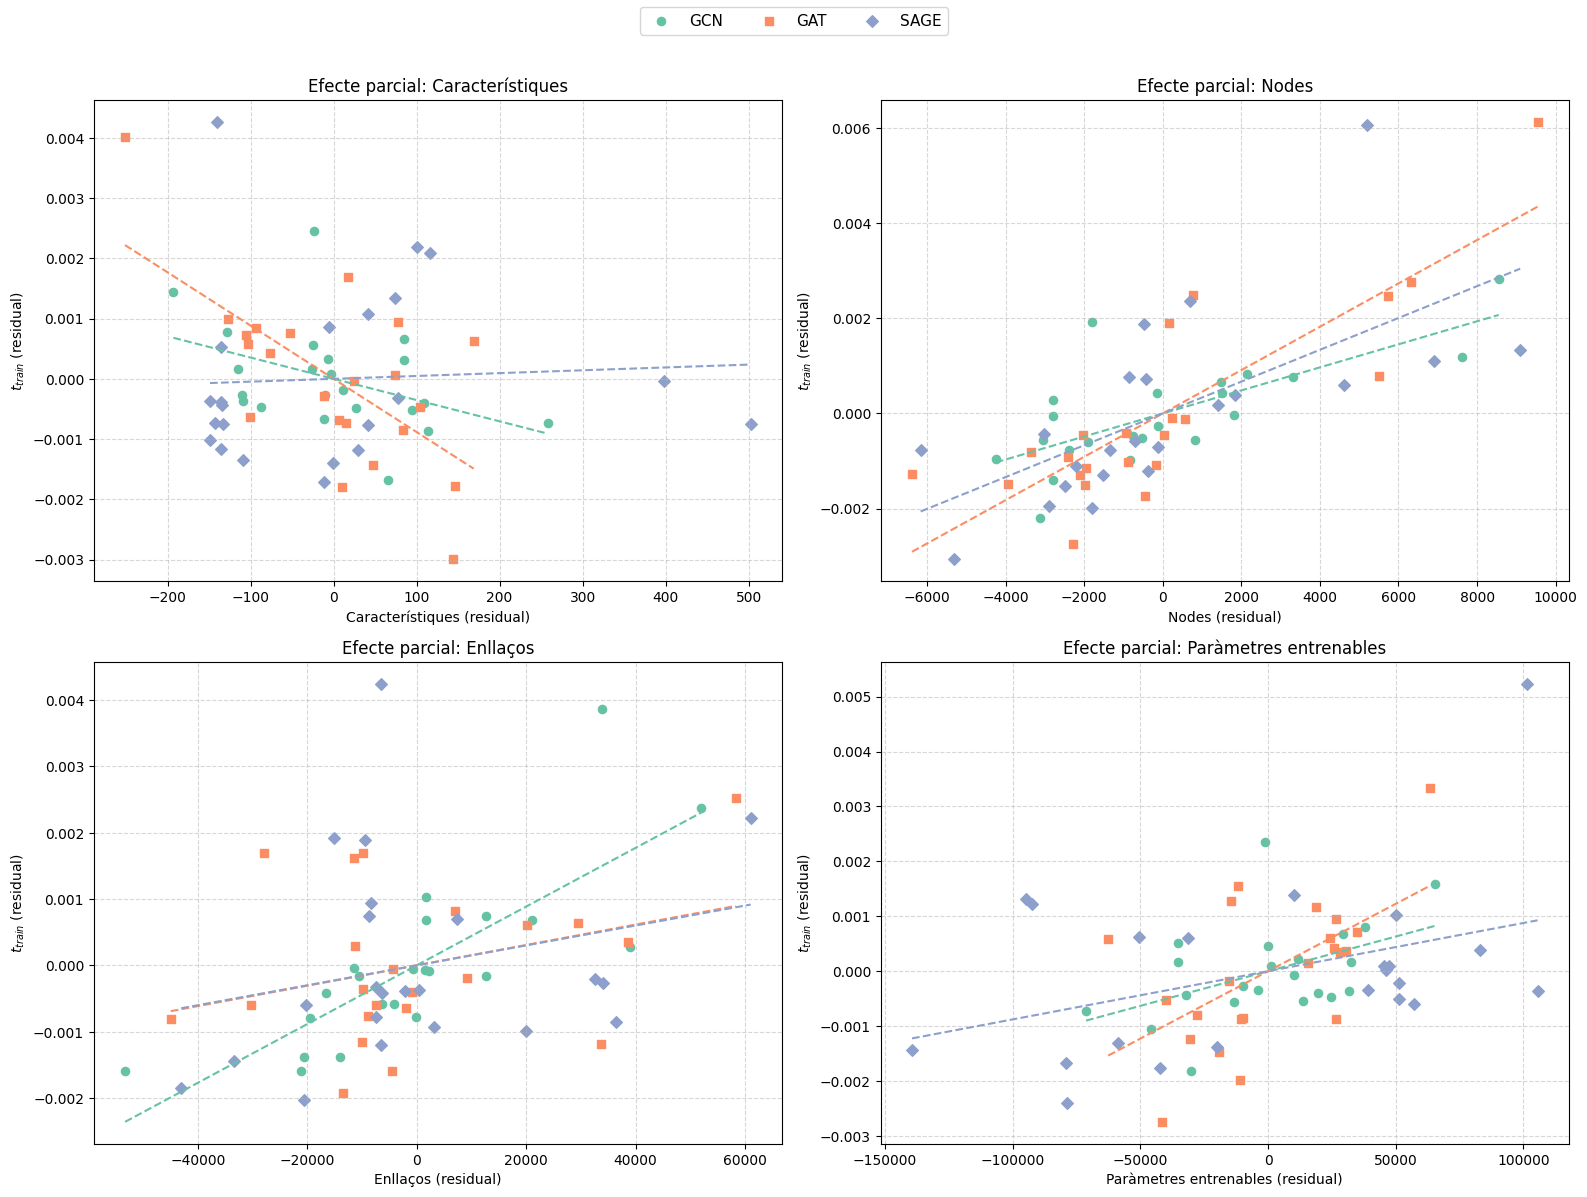

In [46]:
ilvizs.plot_partial_effects(df_performance_total)

Mostrem el valor dels coeficients beta de les regressions per a cada model.

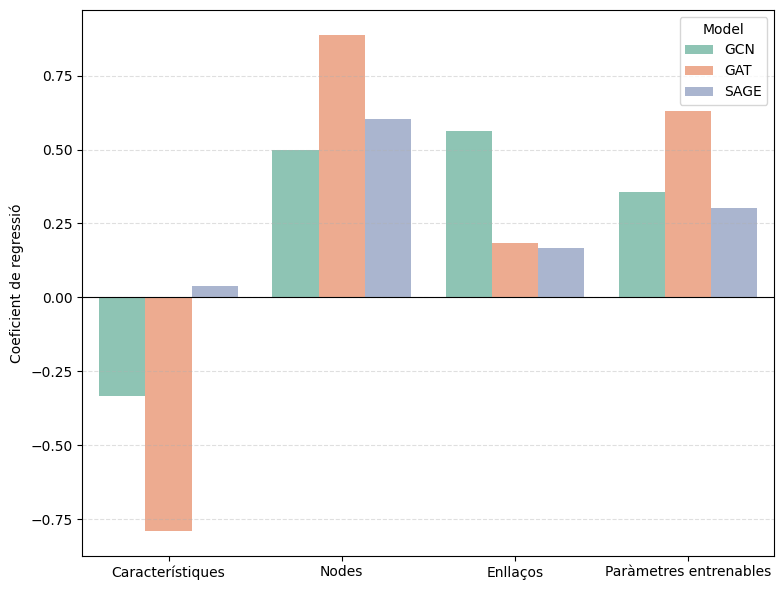

In [83]:
ilvizs.plot_beta_coefficients(df_performance_total)

### Classificació en funció de k

Realitzem proves de classificació per un conjunt gran (UTS1) i un conjunt petit (TUT5) en funció de $k$.

In [ ]:
models = [GCNClassifier, GATClassifier, SAGEClassifier]
dataset_names = ['TUT5']
datasets = {name: name for name in dataset_names}
learning_mode = "transductive"
task = "classification"

splits=10
ks=[1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31,33,35,37,39]

for k in ks:
    for dataset in tqdm(datasets, desc="Datasets"):
        print(dataset + " " + 75*"=")
        dataset_structure = 'sodindoorloc' if dataset.startswith('SOD') else 'ujiindoorloc'
    
        df_original = IndoorLocDataset(
                        dataset_structure=dataset_structure,
                        path=f'../data/{dataset}/{dataset}', 
                        header=None 
        )
        
        df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
            data=df_original, 
            normalization=params_cls[dataset]['graph_params']['normalization'],
            pca_components=params_cls[dataset]['graph_params']['pca_components']
        )
        
        gdata_splits = []
        for i in tqdm(range(splits), desc="Splitting dataset"):
            gdata = IndoorLocGraphData().create_dataloader(
                dataset=df_preprocessed, 
                val_size=0.2,
                graph_method='knn',
                graph_params={
                    'k': k,
                    'metric': params_cls[dataset]['graph_params']['distance_metric'], 
                },
                inductive=True if learning_mode == "inductive" else False,
                n_split=i,
            )
            gdata_splits.append(gdata)
    
        if learning_mode == "inductive":
            gdata = gdata_splits[0].cls['train']
        else:
            gdata = gdata_splits[0].cls
            
        for model in models:
            dataset_model_params = params_cls[dataset]['models'][model.__name__]
            
            print(f"{model.__name__}" + " " + 75*"*" )
            print(
                f"n_layers={2}, "
                f"hidden_dim_layer_0={dataset_model_params['hidden_dim_layer_0']}, "
                f"hidden_dim_layer_1={dataset_model_params['hidden_dim_layer_1']}, "
                f"dropout_layer_0={dataset_model_params['dropout_layer_0']}, "
                f"learning_rate={dataset_model_params['learning_rate']}, "
                f"optim_factor={0.9}, "
                f"weight_decay={dataset_model_params['weight_decay']}, "
                f"mlp_layers={dataset_model_params['mlp_layers']}"
                f"edges={gdata.num_edges}"

            )
    
            model_params = {
                'input_dim': gdata.num_features,
                'hidden_dim': [dataset_model_params['hidden_dim_layer_0'], 
                               dataset_model_params['hidden_dim_layer_1']],
                'output_dim': gdata.num_classes, 
                'n_layers': 2,
                'dropout': [dataset_model_params['dropout_layer_0']],
                'learning_rate': dataset_model_params['learning_rate'],
                'optim_factor': 0.9,
                'weight_decay': dataset_model_params['weight_decay'],
                'mlp_layers': dataset_model_params['mlp_layers']
            }
            if model.__name__ == 'GATClassifier':
                model_params['heads'] = [1, 1]
    
            trainer = GNNClassificationTrainer(dataset=dataset, max_epochs=500, patience=100).run_tests(
                data=gdata_splits, 
                model_class=model,
                parameters=model_params,
                verbose=2,
                show_train_process=False,
                model_path=f"../models/{learning_mode}_{model.__name__}_{dataset}.pth",
                log_path=f"../models/{learning_mode}_{model.__name__}_{dataset}.csv"
            )

### Exactitud en funció de k

Carreguem els resultats i mostrem l'exactitud funció de $k$.

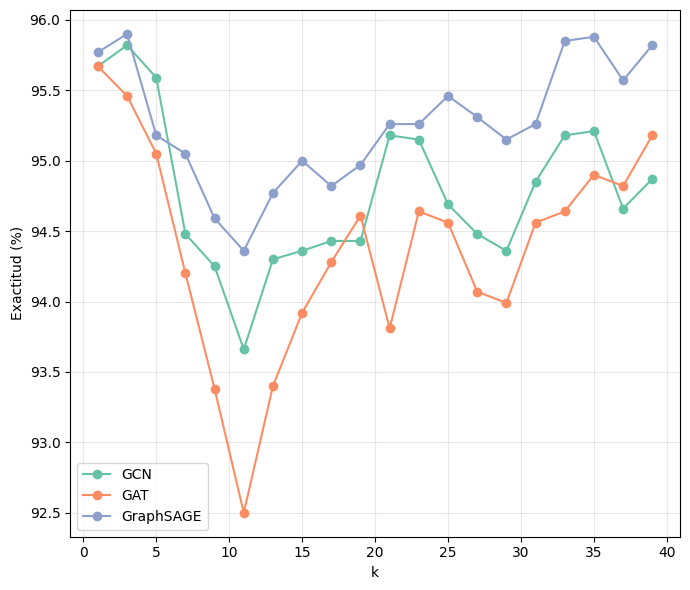

In [100]:
dataset='UTS1'
learning_mode = "transductive"
ks=[1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31,33,35,37,39]

df_k_gcn = pd.read_csv(f"../models/{learning_mode}_{GCNClassifier.__name__}_{dataset}.csv")  
df_k_gat = pd.read_csv(f"../models/{learning_mode}_{GATClassifier.__name__}_{dataset}.csv") 
df_k_sage = pd.read_csv(f"../models/{learning_mode}_{SAGEClassifier.__name__}_{dataset}.csv")  

ilvizs.plot_accuracy_by_k(ks, [df_k_gcn, df_k_gat, df_k_sage])

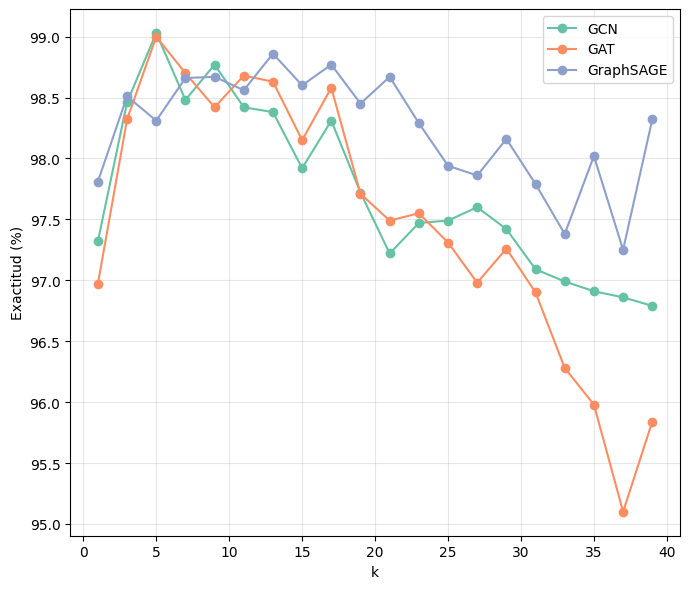

In [96]:
dataset='TUT5'
learning_mode = "transductive"
ks=[1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31,33,35,37,39]

df_k_gcn = pd.read_csv(f"../models/{learning_mode}_{GCNClassifier.__name__}_{dataset}.csv")  
df_k_gat = pd.read_csv(f"../models/{learning_mode}_{GATClassifier.__name__}_{dataset}.csv") 
df_k_sage = pd.read_csv(f"../models/{learning_mode}_{SAGEClassifier.__name__}_{dataset}.csv")  

ilvizs.plot_accuracy_by_k(ks, [df_k_gcn, df_k_gat, df_k_sage])

### Temps en funció de k

Carreguem els resultats i mostrem el temps d'entrenament i inferència en funció de $k$.

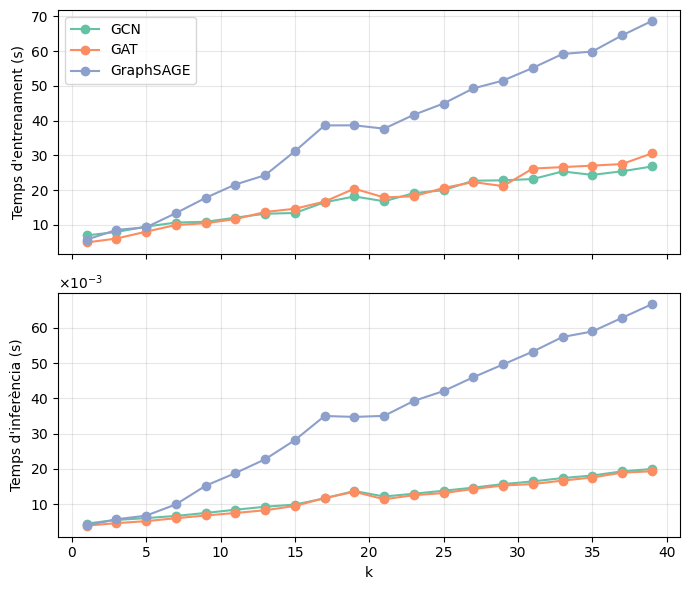

In [101]:
dataset='UTS1'
learning_mode = "transductive"
ks=[1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31,33,35,37,39]

df_k_gcn = pd.read_csv(f"../models/{learning_mode}_{GCNClassifier.__name__}_{dataset}.csv")
df_k_gat = pd.read_csv(f"../models/{learning_mode}_{GATClassifier.__name__}_{dataset}.csv")
df_k_sage = pd.read_csv(f"../models/{learning_mode}_{SAGEClassifier.__name__}_{dataset}.csv")

ilvizs.plot_time_by_k(ks, [df_k_gcn, df_k_gat, df_k_sage])

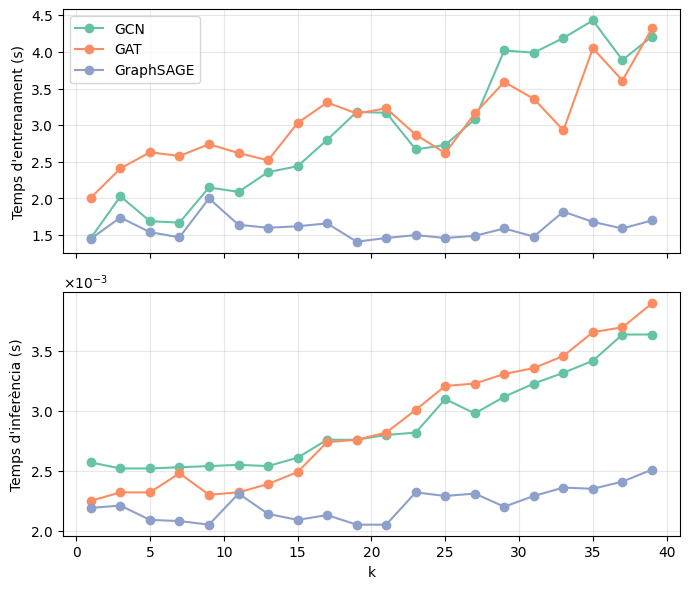

In [99]:
dataset='TUT5'
learning_mode = "transductive"
ks=[1,3,5,7,9,11,13,15,17,19,21,23,25,27,29,31,33,35,37,39]

df_k_gcn = pd.read_csv(f"../models/{learning_mode}_{GCNClassifier.__name__}_{dataset}.csv")
df_k_gat = pd.read_csv(f"../models/{learning_mode}_{GATClassifier.__name__}_{dataset}.csv")
df_k_sage = pd.read_csv(f"../models/{learning_mode}_{SAGEClassifier.__name__}_{dataset}.csv")

ilvizs.plot_time_by_k(ks, [df_k_gcn, df_k_gat, df_k_sage])


### Escalabilitat

Calculem les rectes de regressió del temps d'inferencia i les comparem amb el cost computacional tèoric de k-NN.

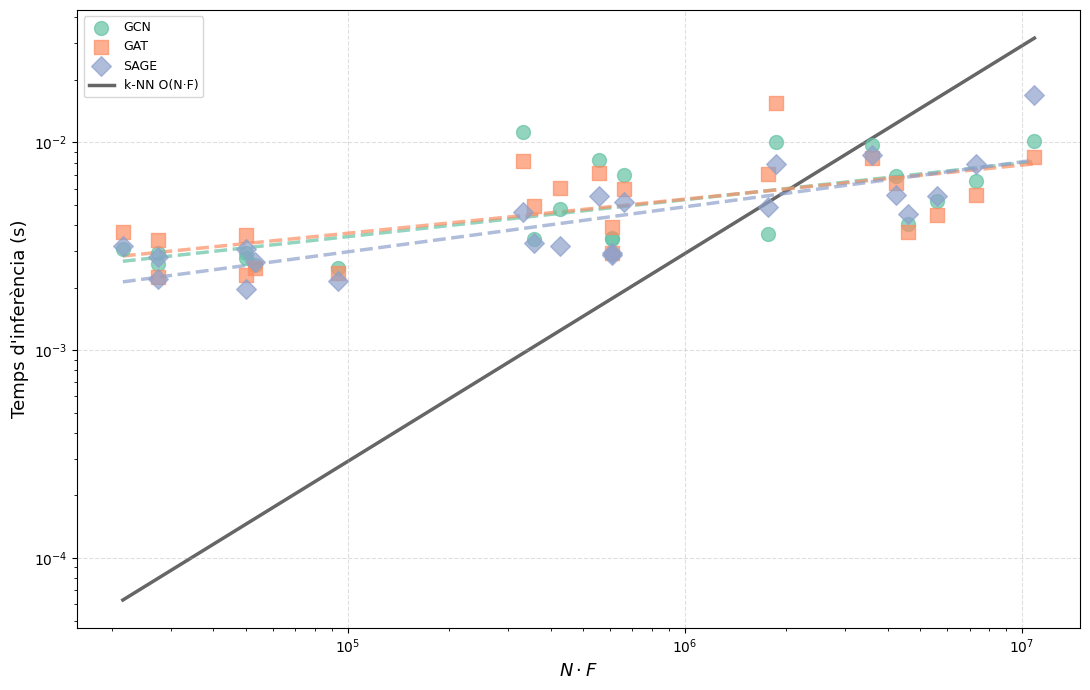

,Model,Exponent,R²
0,GCN,0.177613,0.477526
1,GAT,0.163976,0.415350
2,SAGE,0.216591,0.669477


In [88]:
ilvizs.plot_computational_scaling(df_performance_total)

## Combinacions paramètriques

### Estructura dels grafs

Carreguem configuracions òptimes dels grafs.

In [67]:
counts_norm_reg = {'Lineal': 5, 'Potència': 7}
counts_norm_clf = {'Lineal': 3, 'Potència': 7}
counts_pca_reg = {90: 4, 95: 5, 100: 3}
counts_pca_clf = {90: 2, 95: 3, 100: 5}
counts_met_reg = {'Cosinus': 9, 'Manhattan': 3}
counts_met_clf = {'Cosinus': 4, 'Manhattan': 6}
counts_k_reg = {1: 4, 3: 3, 7: 3, 11: 2}
counts_k_clf = {1: 0, 3: 8, 7: 2, 11:0 }

Mostrem grid amb les gràfiques.

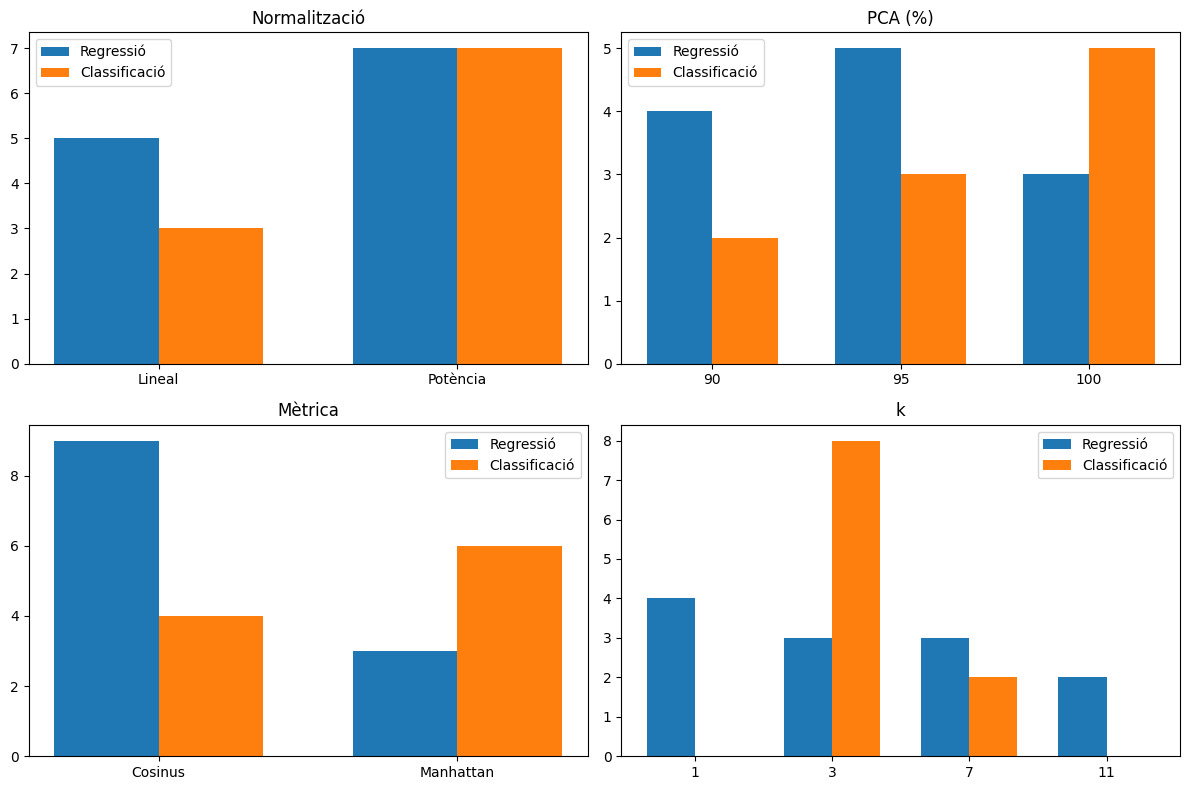

In [68]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

ilvizs.grouped_bars(axs[0, 0], counts_norm_reg, counts_norm_clf, 'Normalització')
ilvizs.grouped_bars(axs[0, 1], counts_pca_reg, counts_pca_clf, 'PCA (%)')
ilvizs.grouped_bars(axs[1, 0], counts_met_reg, counts_met_clf, 'Mètrica')
ilvizs.grouped_bars(axs[1, 1], counts_k_reg, counts_k_clf, 'k')

plt.tight_layout()
plt.show()

### Models base

Carreguem combinacions òptimes obtingudes.

In [63]:
configs = {
    1:  {'dims': '[128,128]', 'dropout': 0.4, 'lr': '5e-3',  'wd': '1e-4', 'mlp': 4},
    2:  {'dims': '[128,128]', 'dropout': 0.6, 'lr': '5e-3',  'wd': '1e-5', 'mlp': 2},
    3:  {'dims': '[128,128]', 'dropout': 0.6, 'lr': '1e-2',  'wd': '1e-4', 'mlp': 2},
    4:  {'dims': '[128,128]', 'dropout': 0.6, 'lr': '1e-2',  'wd': '1e-4', 'mlp': 4},
    5:  {'dims': '[128,256]', 'dropout': 0.4, 'lr': '1e-2',  'wd': '1e-4', 'mlp': 2},
    6:  {'dims': '[128,256]', 'dropout': 0.6, 'lr': '5e-3',  'wd': '1e-5', 'mlp': 2},
    7:  {'dims': '[128,256]', 'dropout': 0.6, 'lr': '5e-3',  'wd': '1e-5', 'mlp': 4},
    8:  {'dims': '[128,256]', 'dropout': 0.6, 'lr': '1e-2',  'wd': '1e-5', 'mlp': 4},
    9:  {'dims': '[128,256]', 'dropout': 0.6, 'lr': '1e-2',  'wd': '1e-4', 'mlp': 2},
    10: {'dims': '[128,256]', 'dropout': 0.6, 'lr': '1e-2',  'wd': '1e-4', 'mlp': 4},
    11: {'dims': '[256,128]', 'dropout': 0.4, 'lr': '1e-2',  'wd': '1e-5', 'mlp': 2},
    12: {'dims': '[256,128]', 'dropout': 0.6, 'lr': '5e-3',  'wd': '1e-5', 'mlp': 2},
    13: {'dims': '[256,128]', 'dropout': 0.6, 'lr': '5e-3',  'wd': '1e-5', 'mlp': 4},
    14: {'dims': '[256,128]', 'dropout': 0.6, 'lr': '1e-2',  'wd': '1e-4', 'mlp': 2},
    15: {'dims': '[256,128]', 'dropout': 0.6, 'lr': '1e-2',  'wd': '1e-4', 'mlp': 4},
    16: {'dims': '[256,256]', 'dropout': 0.4, 'lr': '5e-3',  'wd': '1e-4', 'mlp': 2},
    17: {'dims': '[256,256]', 'dropout': 0.4, 'lr': '1e-2',  'wd': '1e-5', 'mlp': 4},
    18: {'dims': '[256,256]', 'dropout': 0.4, 'lr': '1e-2',  'wd': '1e-4', 'mlp': 2},
    19: {'dims': '[256,256]', 'dropout': 0.6, 'lr': '5e-3',  'wd': '1e-5', 'mlp': 2},
    20: {'dims': '[256,256]', 'dropout': 0.6, 'lr': '5e-3',  'wd': '1e-4', 'mlp': 2},
    21: {'dims': '[256,256]', 'dropout': 0.6, 'lr': '1e-2',  'wd': '1e-4', 'mlp': 2},
    22: {'dims': '[256,256]', 'dropout': 0.6, 'lr': '1e-2',  'wd': '1e-4', 'mlp': 4},
}

ids_reg = [
    15, 21, 10,  # UJI1
    3, 16, 21,   # UTS1
    9, 21, 1,    # SOD01
    21, 15, 15,  # SOD02
    18, 14, 14,  # SOD06
    21, 14, 21,  # SAH1
    10, 9, 9,    # TIE1
    21, 21, 18,  # TUT1
    14, 21, 4,   # TUT2
    9, 3, 22,    # TUT3
    21, 10, 22,  # TUT4
    21, 21, 22   # TUT5
]

ids_clf = [
    9, 5, 22,    # UJI1
    11, 8, 2,    # UTS1
    21, 21, 21,  # SOD01
    20, 20, 14,  # SAH1
    13, 13, 13,  # TIE1
    9, 9, 9,     # TUT1
    14, 14, 12,  # TUT2
    6, 9, 20,    # TUT3
    19, 17, 7,   # TUT4
    9, 9, 21     # TUT5
]


Calculem els comptes per cada paràmetre.

In [64]:
dims_reg = ilvizs.count_param(configs, ids_reg, 'dims')
dims_clf = ilvizs.count_param(configs, ids_clf, 'dims')
mlp_reg = ilvizs.count_param(configs, ids_reg, 'mlp')
mlp_clf = ilvizs.count_param(configs, ids_clf, 'mlp')
dropout_reg = ilvizs.count_param(configs, ids_reg, 'dropout')
dropout_clf = ilvizs.count_param(configs, ids_clf, 'dropout')
lr_reg = ilvizs.count_param(configs, ids_reg, 'lr')
lr_clf = ilvizs.count_param(configs, ids_clf, 'lr')
wd_reg = ilvizs.count_param(configs, ids_reg, 'wd')
wd_clf = ilvizs.count_param(configs, ids_clf, 'wd')

Mostrem grid amb les gràfiques.

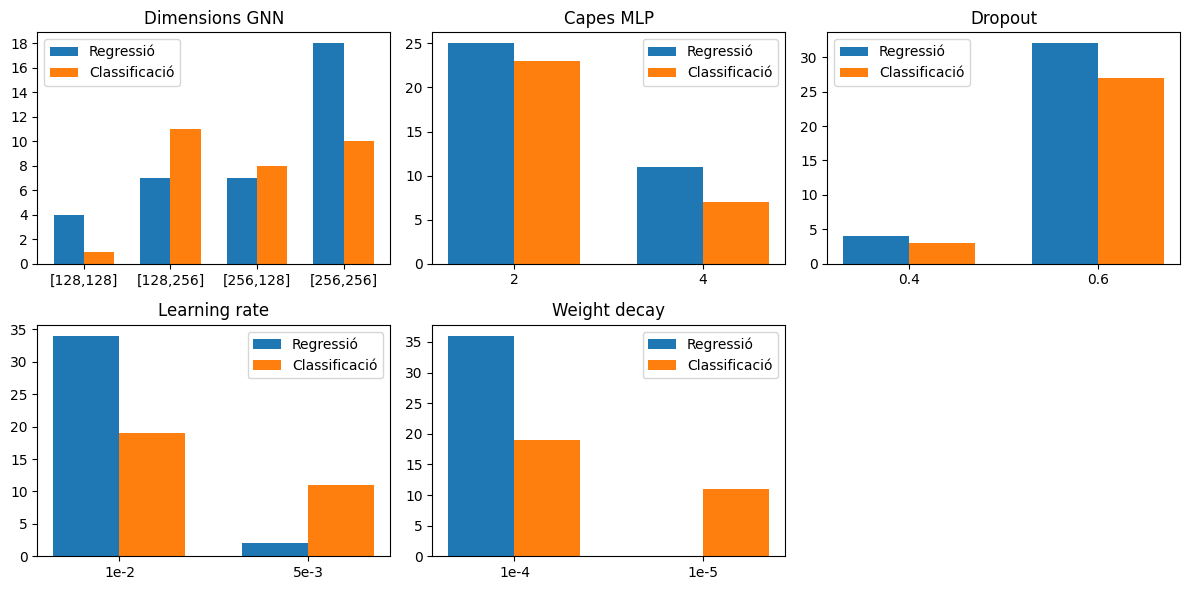

In [66]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

ilvizs.grouped_bars(axs[0, 0], dims_reg, dims_clf, 'Dimensions GNN')
ilvizs.grouped_bars(axs[0, 1], mlp_reg, mlp_clf, 'Capes MLP')
ilvizs.grouped_bars(axs[0, 2], dropout_reg, dropout_clf, 'Dropout')
ilvizs.grouped_bars(axs[1, 0], lr_reg, lr_clf, 'Learning rate')
ilvizs.grouped_bars(axs[1, 1], wd_reg, wd_clf, 'Weight decay')

axs[0, 0].yaxis.set_major_locator(MaxNLocator(integer=True))
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()